# Final Project: Unsupervised Learning, Dimensionality Reduction, and Anomaly Detection

## Introduction

In this project, we analyze a real-world credit card customer dataset using unsupervised learning techniques.

Unlike supervised learning tasks, no labels are provided. Therefore, our objective is to explore the underlying structure of the data and identify meaningful patterns without prior knowledge of customer categories.

The analysis focuses on three major aspects:

1. Exploratory Data Analysis (EDA)
2. Dimensionality Reduction using Principal Component Analysis (PCA)
3. Clustering and Multi-Dimensional Anomaly Detection

The dataset contains behavioral information for approximately 9,000 credit card customers, including balance information, purchase activity, cash advances, payment behavior, and credit limits.

Through this analysis, we aim to answer the following questions:

- Can meaningful customer groups be discovered automatically?
- Which variables contain the most information?
- Are there hidden structures within the data?
- Can unusual customer behaviors be detected without predefined labels?

The project follows the methodology required in the course assignment and includes critical discussion of the strengths and limitations of each technique.

In [ ]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy.stats import skew, kurtosis, zscore

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering

# Anomaly Detection
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Evaluation
from sklearn.metrics import silhouette_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style="whitegrid")

# Reproducibility
RANDOM_STATE = 42

In [ ]:
df = pd.read_csv("CC GENERAL.csv")

print(f"Dataset shape: {df.shape}")

df.head()

Dataset shape: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [ ]:
print("Rows and Columns:")
display(df.shape)

print("\nColumn Names:")
display(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

Rows and Columns:


(8950, 18)


Column Names:


['CUST_ID',
 'BALANCE',
 'BALANCE_FREQUENCY',
 'PURCHASES',
 'ONEOFF_PURCHASES',
 'INSTALLMENTS_PURCHASES',
 'CASH_ADVANCE',
 'PURCHASES_FREQUENCY',
 'ONEOFF_PURCHASES_FREQUENCY',
 'PURCHASES_INSTALLMENTS_FREQUENCY',
 'CASH_ADVANCE_FREQUENCY',
 'CASH_ADVANCE_TRX',
 'PURCHASES_TRX',
 'CREDIT_LIMIT',
 'PAYMENTS',
 'MINIMUM_PAYMENTS',
 'PRC_FULL_PAYMENT',
 'TENURE']


Data Types:


,0
CUST_ID,object
BALANCE,float64
BALANCE_FREQUENCY,float64
PURCHASES,float64
ONEOFF_PURCHASES,float64
INSTALLMENTS_PURCHASES,float64
CASH_ADVANCE,float64
PURCHASES_FREQUENCY,float64
ONEOFF_PURCHASES_FREQUENCY,float64
PURCHASES_INSTALLMENTS_FREQUENCY,float64


## Initial Dataset Overview

The dataset contains behavioral information for approximately 9,000 credit card customers over a six-month period.

Each row represents a customer, while the columns describe various aspects of credit card usage, including balances, purchases, cash advances, payment behavior, and credit limits.

Before applying dimensionality reduction, clustering, or anomaly detection techniques, it is important to understand the structure and quality of the data through an exploratory data analysis process.

# 1. Dataset Selection

## Dataset Source

The dataset used in this project is the Credit Card Dataset for Clustering, obtained from Kaggle.

It contains information about 8,950 credit card customers and their activity over a six-month period.

## Purpose of the Dataset

The dataset was collected to analyze customer behavior and support customer segmentation.

## Data Collector

The dataset was published on Kaggle by Arjun Bhasin. The original source of the data is not specified.

## Features

The dataset contains financial and behavioral information about credit card customers.

Some of the variables include:

- BALANCE: current account balance
- PURCHASES: total purchase amount
- CASH_ADVANCE: cash advances taken by the customer
- CREDIT_LIMIT: customer credit limit
- PAYMENTS: payments made by the customer
- TENURE: customer activity period

Additional features describe purchase frequency, payment behavior, and cash advance activity.

## Limitations

- The original data source is unknown.
- No demographic information is available.
- The data covers only six months.
- Some missing values exist in the dataset.

In [ ]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 8950
Number of columns: 18


The dataset contains 8,950 rows and 18 columns.
Each row represents a customer and each column represents a customer attribute or behavioral measure.

In [ ]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

,0
CREDIT_LIMIT,1
MINIMUM_PAYMENTS,313


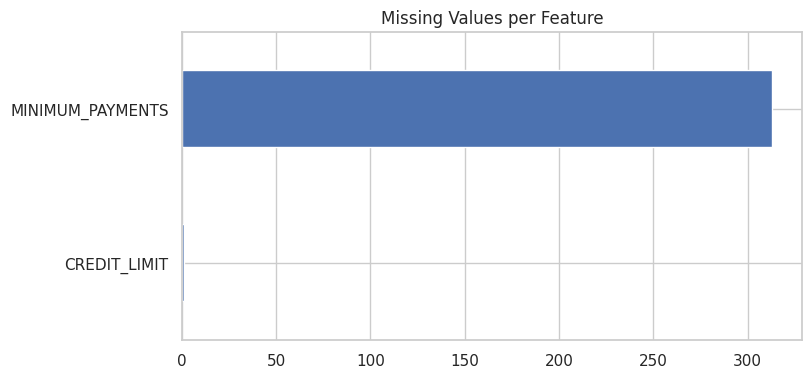

In [ ]:
plt.figure(figsize=(8,4))
missing_values[missing_values > 0].sort_values().plot(kind='barh')
plt.title("Missing Values per Feature")
plt.show()

Most features contain no missing values.

Missing values appear mainly in MINIMUM_PAYMENTS and CREDIT_LIMIT, which will require preprocessing before applying machine learning algorithms.

In [ ]:
df.dtypes

,0
CUST_ID,object
BALANCE,float64
BALANCE_FREQUENCY,float64
PURCHASES,float64
ONEOFF_PURCHASES,float64
INSTALLMENTS_PURCHASES,float64
CASH_ADVANCE,float64
PURCHASES_FREQUENCY,float64
ONEOFF_PURCHASES_FREQUENCY,float64
PURCHASES_INSTALLMENTS_FREQUENCY,float64


Most variables are numerical.

The only categorical variable is CUST_ID, which serves as a customer identifier and will not be used in the analysis.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


The summary statistics show large differences between feature scales.

For example, variables such as PURCHASES and CREDIT_LIMIT have much larger ranges than frequency-based variables, indicating that scaling will be necessary before applying PCA and clustering methods.

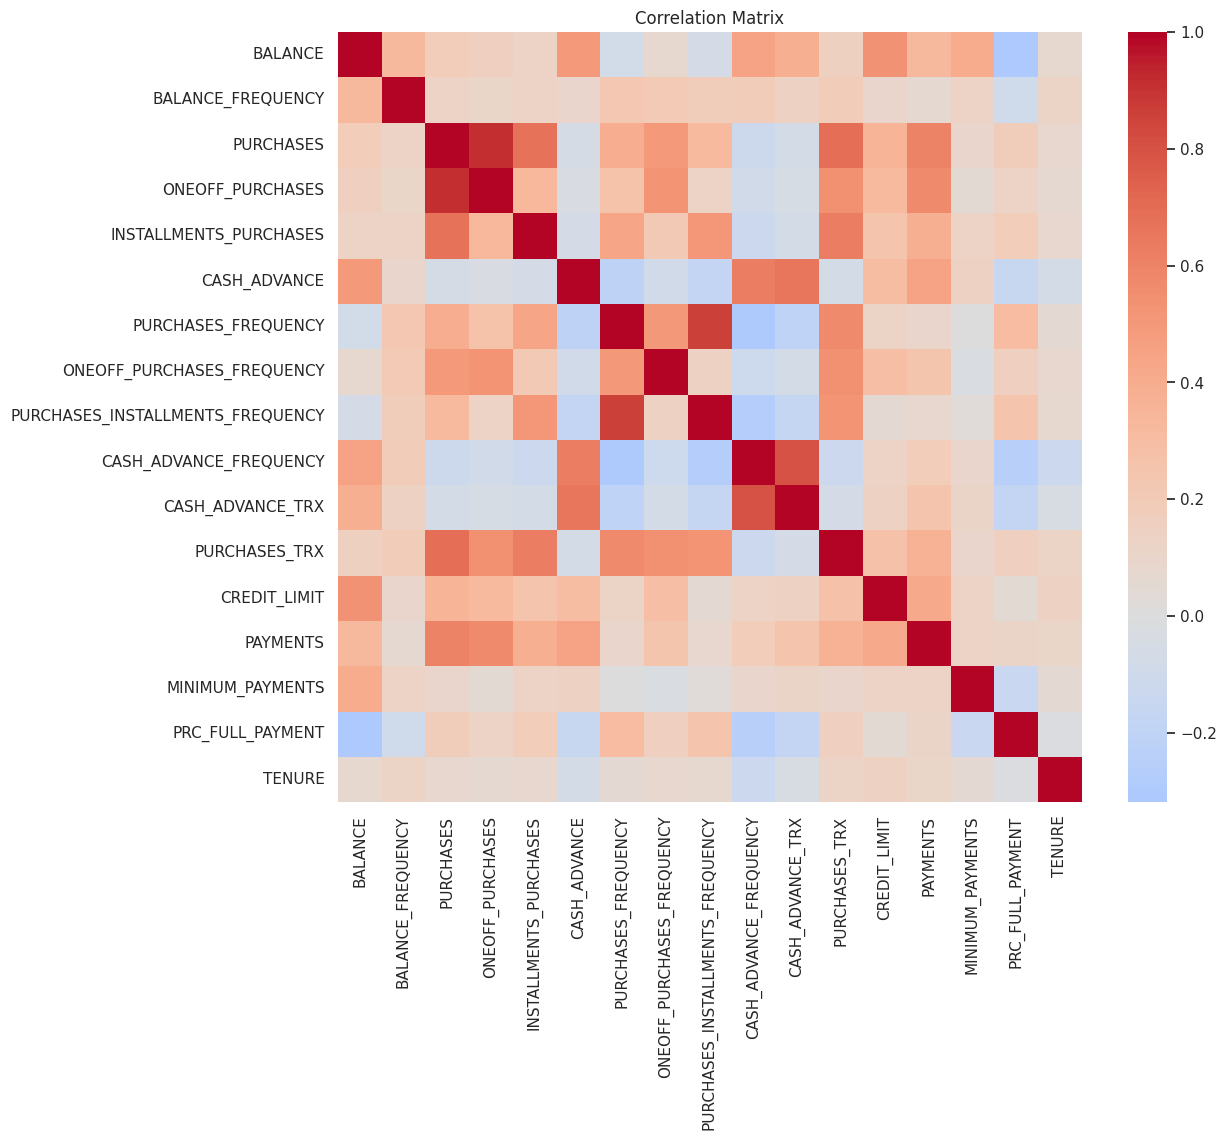

In [ ]:
plt.figure(figsize=(12,10))

sns.heatmap(
    df.drop(columns=['CUST_ID']).corr(),
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Matrix")
plt.show()

Several features show moderate to strong correlations.

This suggests that some variables may contain overlapping information, making PCA a useful tool for dimensionality reduction.

In [ ]:
major_features = [
    "BALANCE",
    "PURCHASES",
    "CASH_ADVANCE",
    "CREDIT_LIMIT",
    "PAYMENTS"
]

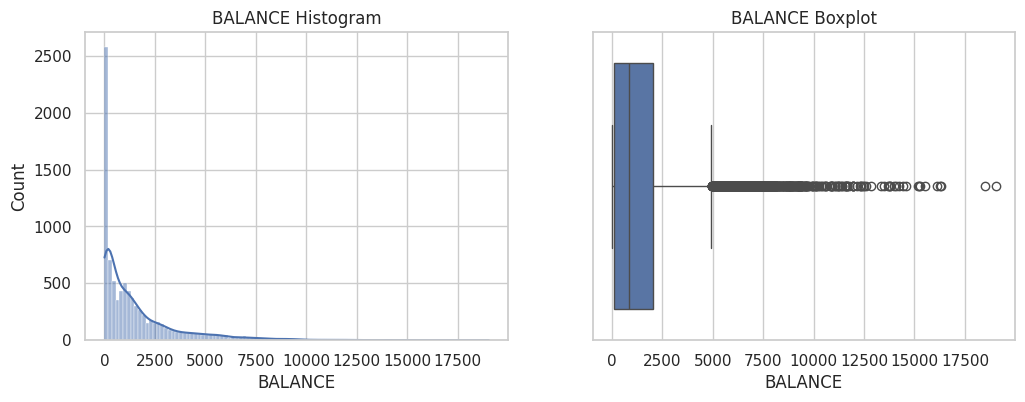

Skewness: 2.39
Kurtosis: 7.67


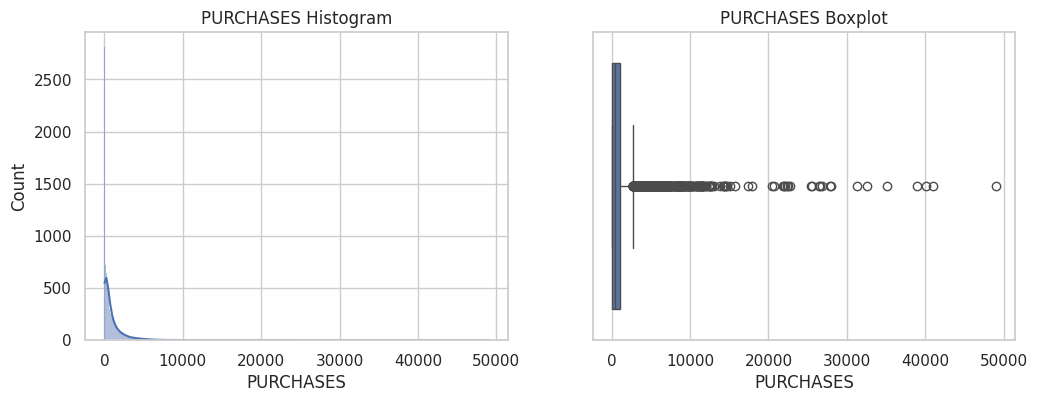

Skewness: 8.14
Kurtosis: 111.33


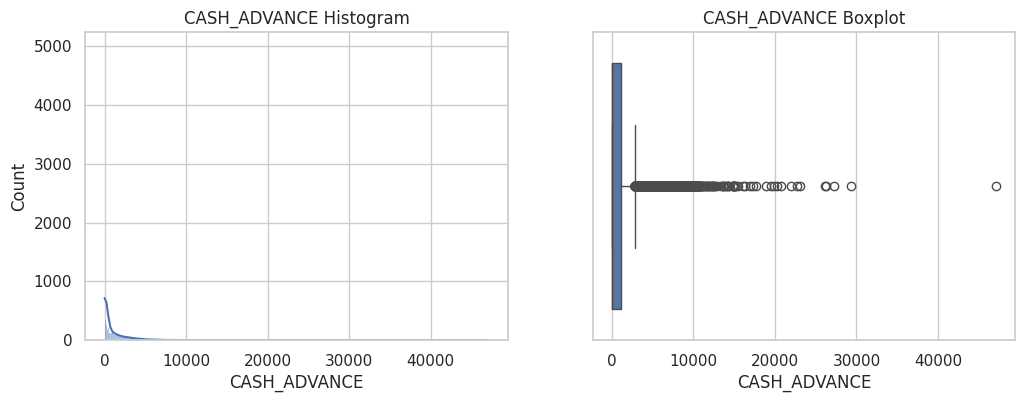

Skewness: 5.17
Kurtosis: 52.87


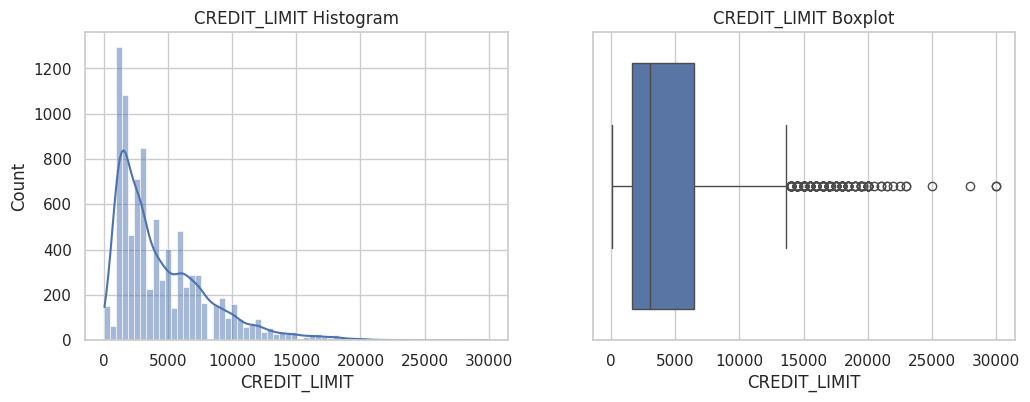

Skewness: 1.52
Kurtosis: 2.83


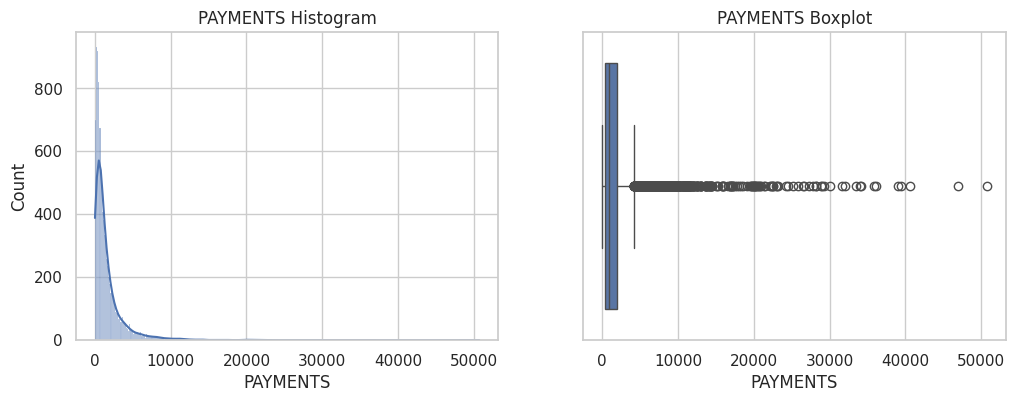

Skewness: 5.91
Kurtosis: 54.74


In [ ]:
for feature in major_features:

    fig, axes = plt.subplots(1, 2, figsize=(12,4))

    sns.histplot(df[feature], kde=True, ax=axes[0])
    axes[0].set_title(f"{feature} Histogram")

    sns.boxplot(x=df[feature], ax=axes[1])
    axes[1].set_title(f"{feature} Boxplot")

    plt.show()

    print(f"Skewness: {skew(df[feature].dropna()):.2f}")
    print(f"Kurtosis: {kurtosis(df[feature].dropna()):.2f}")

### Distribution Analysis

Most of the analyzed features are positively skewed, meaning that most customers have relatively low values, while a small number of customers have very high values.

PURCHASES, CASH_ADVANCE, and PAYMENTS exhibit particularly high skewness and kurtosis values. This indicates the presence of extreme observations and long right tails.

The boxplots support this observation, showing many outliers in these variables. These customers may represent unusual spending or payment behavior compared to the majority of the population.

CREDIT_LIMIT appears less extreme than the other variables, although it is still not perfectly symmetric.

Overall, the distributions suggest that the dataset is not normally distributed and contains substantial variability between customers. These characteristics make the dataset suitable for clustering and anomaly detection analyses.

# 3. Dimensionality Reduction

In [ ]:
pca_df = df.copy()

pca_df = pca_df.drop(columns=['CUST_ID'])

pca_df['MINIMUM_PAYMENTS'] = pca_df['MINIMUM_PAYMENTS'].fillna(
    pca_df['MINIMUM_PAYMENTS'].median()
)

pca_df['CREDIT_LIMIT'] = pca_df['CREDIT_LIMIT'].fillna(
    pca_df['CREDIT_LIMIT'].median()
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_df)

In [ ]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

In [ ]:
explained_variance_ratio = pca.explained_variance_ratio_

pd.DataFrame({
    'PC': np.arange(1, len(explained_variance_ratio)+1),
    'Explained Variance Ratio': explained_variance_ratio
})

,PC,Explained Variance Ratio
0,1,2.729767e-01
1,2,2.031378e-01
2,3,8.813182e-02
3,4,7.479524e-02
4,5,6.224729e-02
5,6,5.740056e-02
6,7,4.883426e-02
7,8,4.299203e-02
8,9,3.798259e-02
9,10,3.080002e-02


In [ ]:
cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

pd.DataFrame({
    'PC': np.arange(1, len(cumulative_variance)+1),
    'Cumulative Variance': cumulative_variance
})

,PC,Cumulative Variance
0,1,0.272977
1,2,0.476115
2,3,0.564246
3,4,0.639042
4,5,0.701289
5,6,0.758689
6,7,0.807524
7,8,0.850516
8,9,0.888498
9,10,0.919298


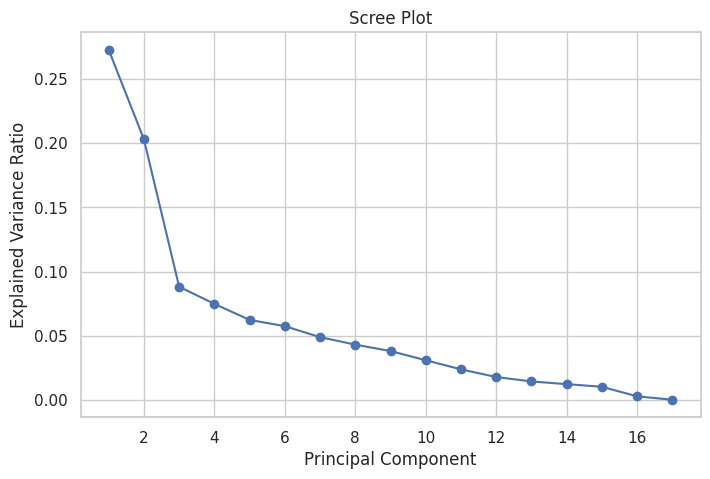

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(explained_variance_ratio)+1),
    explained_variance_ratio,
    marker='o'
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")

plt.show()

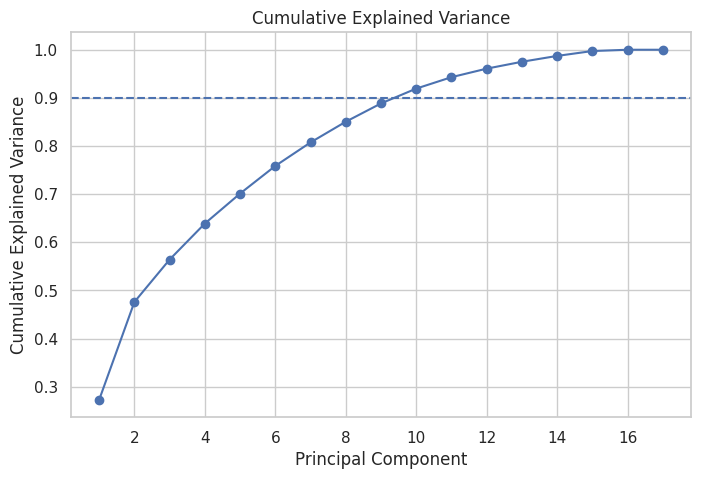

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance,
    marker='o'
)

plt.axhline(
    y=0.9,
    linestyle='--'
)

plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")

plt.show()

## PCA Results and Discussion

The PCA results show that the first principal component explains approximately 27.3% of the total variance, while the first two components together explain about 47.6%.

The cumulative explained variance reaches approximately 70.1% with the first five components and exceeds 90% after ten components. This indicates that the original dataset can be represented using a smaller number of dimensions while preserving most of the information.

The scree plot shows a sharp decrease after the first two components, followed by a more gradual decline. This suggests that the first few components capture most of the important structure in the data, while later components contribute relatively little additional information.

The fact that a small number of components explain a large portion of the variance suggests that some of the original variables are correlated and contain overlapping information. This observation is consistent with the correlation analysis performed earlier.

Using only two principal components would result in a substantial information loss, since more than half of the variance remains unexplained. In contrast, using approximately ten components preserves over 90% of the variance and therefore provides a good balance between dimensionality reduction and information retention.

Overall, the PCA analysis indicates that the dataset contains meaningful underlying structure and redundancy among variables, making dimensionality reduction beneficial for subsequent clustering and anomaly detection tasks.

# 4. Clustering Analysis

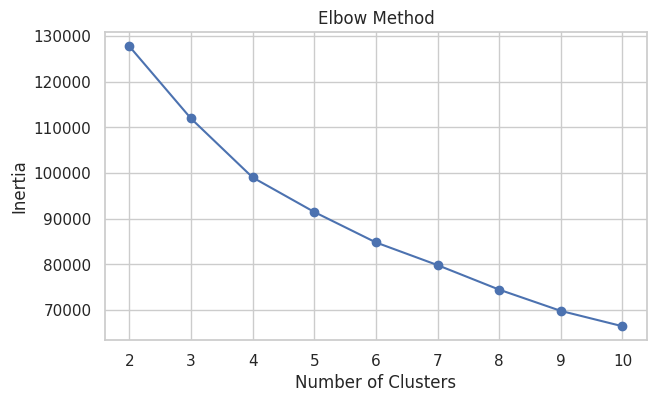

In [22]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7,4))
plt.plot(range(2,11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [23]:
kmeans = KMeans(
    n_clusters=4,
    random_state=RANDOM_STATE,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

In [24]:
silhouette_kmeans = silhouette_score(
    X_scaled,
    kmeans_labels
)

print("Silhouette Score:", silhouette_kmeans)

Silhouette Score: 0.1976791965228765


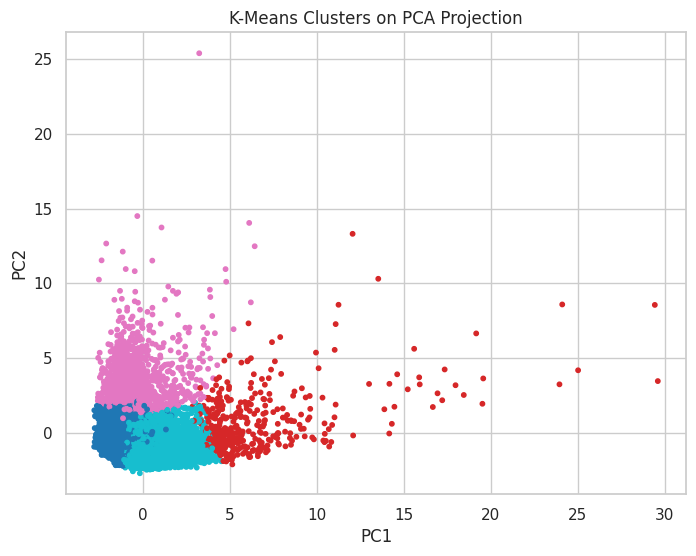

In [25]:
pca_vis = PCA(n_components=2)
X_vis = pca_vis.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=kmeans_labels,
    cmap='tab10',
    s=10
)

plt.title("K-Means Clusters on PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [26]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=10
)

dbscan_labels = dbscan.fit_predict(X_scaled)

In [27]:
unique_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

print("Clusters:", unique_clusters)

if unique_clusters > 1:
    print(
        silhouette_score(
            X_scaled,
            dbscan_labels
        )
    )

Clusters: 1


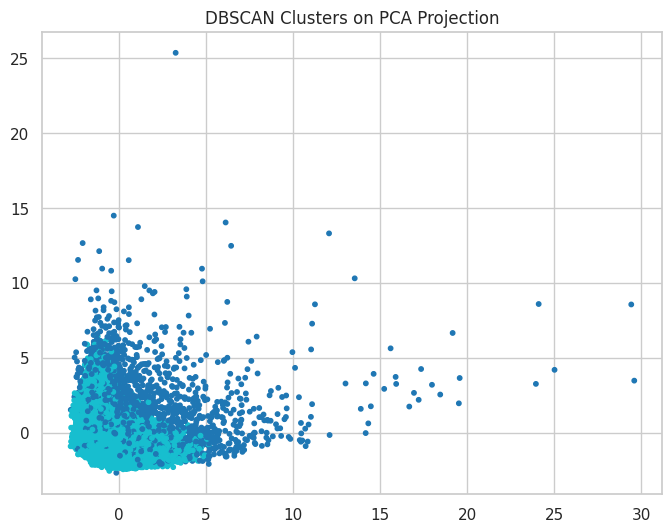

In [28]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=dbscan_labels,
    cmap='tab10',
    s=10
)

plt.title("DBSCAN Clusters on PCA Projection")
plt.show()

In [29]:
hierarchical = AgglomerativeClustering(
    n_clusters=4
)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

In [30]:
silhouette_hierarchical = silhouette_score(
    X_scaled,
    hierarchical_labels
)

print(
    "Silhouette:",
    silhouette_hierarchical
)

Silhouette: 0.15978366986218748


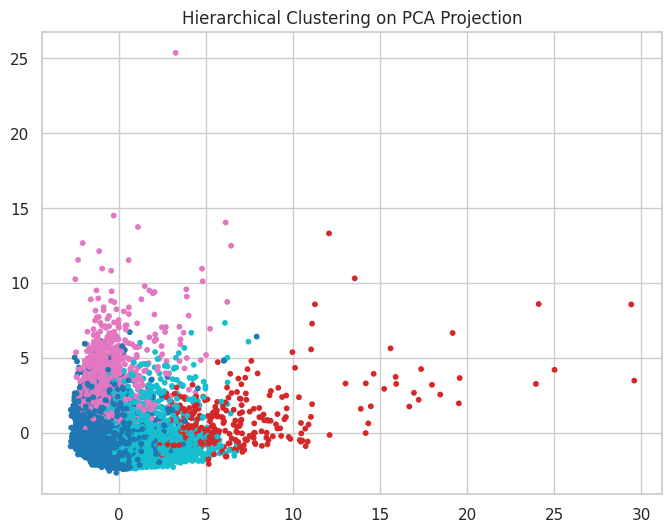

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=hierarchical_labels,
    cmap='tab10',
    s=10
)

plt.title("Hierarchical Clustering on PCA Projection")
plt.show()

In [32]:
feature_matrix = X_scaled.T

In [34]:
feature_kmeans = KMeans(
    n_clusters=3,
    random_state=RANDOM_STATE,
    n_init=10
)

feature_labels = feature_kmeans.fit_predict(
    feature_matrix
)

feature_clusters = pd.DataFrame({
    "Feature": pca_df.columns,
    "Cluster": feature_labels
})

feature_clusters.sort_values("Cluster")

,Feature,Cluster
5,CASH_ADVANCE,0
9,CASH_ADVANCE_FREQUENCY,0
10,CASH_ADVANCE_TRX,0
3,ONEOFF_PURCHASES,1
6,PURCHASES_FREQUENCY,1
7,ONEOFF_PURCHASES_FREQUENCY,1
4,INSTALLMENTS_PURCHASES,1
2,PURCHASES,1
13,PAYMENTS,1
15,PRC_FULL_PAYMENT,1


In [35]:
print("K-Means:", silhouette_score(X_scaled, kmeans_labels))
print("Hierarchical:", silhouette_score(X_scaled, hierarchical_labels))

K-Means: 0.1976791965228765
Hierarchical: 0.15978366986218748


K-Means achieved a slightly higher silhouette score than Hierarchical Clustering, suggesting better cluster separation.

## Clustering Results and Discussion

### K-Means

Based on the Elbow plot, 4 clusters were selected.

The PCA projection shows that K-Means successfully separates the customers into several groups, although some overlap between clusters remains visible.

### DBSCAN

DBSCAN identified only a single cluster using the selected parameters.

This suggests that the dataset does not contain clearly separated density-based groups, or that different hyperparameters are required.

### Hierarchical Clustering

Hierarchical clustering produced results similar to K-Means.

The clusters show some separation, but overlap is still present in several regions of the PCA projection.

### Feature Space Clustering

Feature clustering revealed meaningful groups of related variables.

Cash advance features were grouped together, purchase and payment features formed another group, and balance-related features formed a third group.

This indicates that several variables contain related information and describe similar customer behaviors.

### Discussion

Different clustering methods produced different results because they rely on different assumptions about the data.

K-Means and Hierarchical Clustering identified meaningful customer groups, while DBSCAN was less effective for the selected parameters.

Overall, the results suggest that the dataset contains underlying structure, but the customer groups are not completely separated.

# 5. Multi-Dimensional Anomaly Detection

In this section, we apply and compare three anomaly detection methods in order to identify unusual customer behaviors in the dataset.

In [36]:
z_scores = np.abs(zscore(pca_df))

z_anomalies = (z_scores > 3).any(axis=1)

print("Number of anomalies:", z_anomalies.sum())
print("Percentage:", round(100 * z_anomalies.mean(), 2), "%")

Number of anomalies: 1516
Percentage: 16.94 %


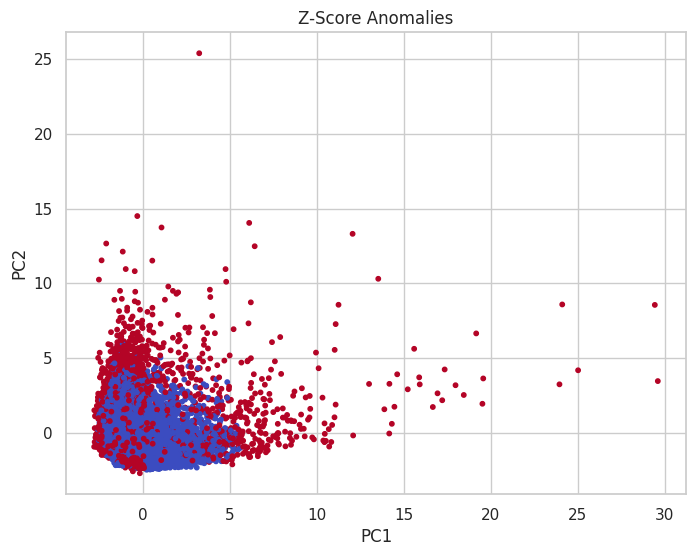

In [37]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=z_anomalies,
    cmap='coolwarm',
    s=10
)

plt.title("Z-Score Anomalies")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [38]:
isolation_forest = IsolationForest(
    contamination=0.05,
    random_state=RANDOM_STATE
)

if_labels = isolation_forest.fit_predict(X_scaled)

if_anomalies = (if_labels == -1)

print("Number of anomalies:", if_anomalies.sum())
print("Percentage:", round(100 * if_anomalies.mean(), 2), "%")

Number of anomalies: 448
Percentage: 5.01 %


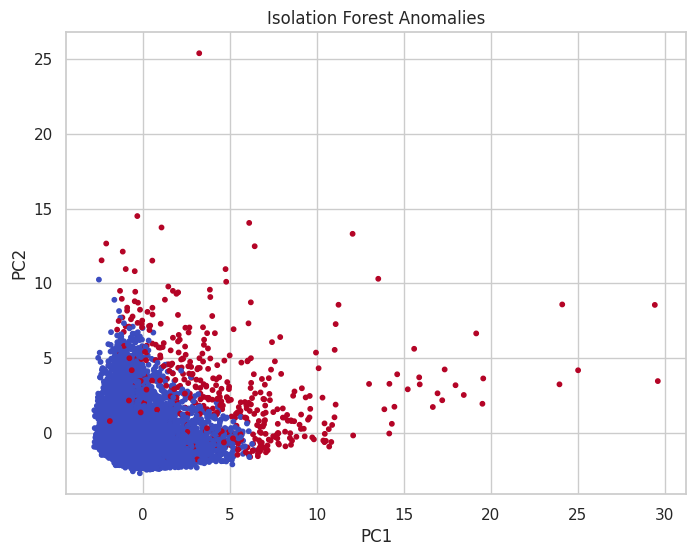

In [39]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=if_anomalies,
    cmap='coolwarm',
    s=10
)

plt.title("Isolation Forest Anomalies")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [40]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05
)

lof_labels = lof.fit_predict(X_scaled)

lof_anomalies = (lof_labels == -1)

print("Number of anomalies:", lof_anomalies.sum())
print("Percentage:", round(100 * lof_anomalies.mean(), 2), "%")

Number of anomalies: 448
Percentage: 5.01 %


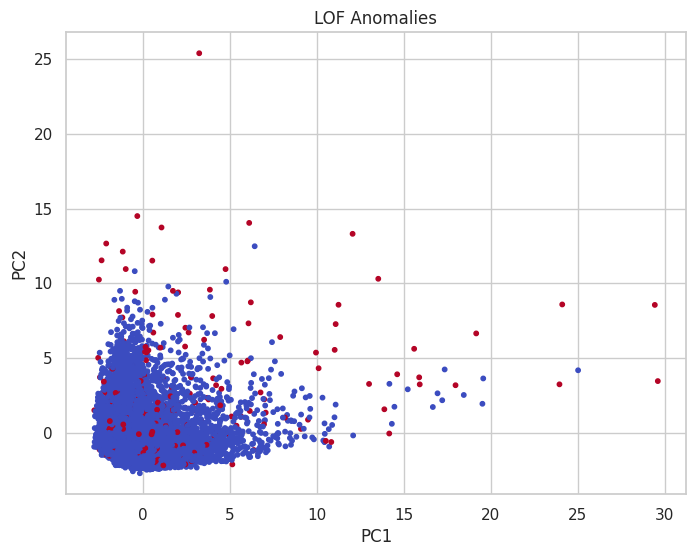

In [41]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=lof_anomalies,
    cmap='coolwarm',
    s=10
)

plt.title("LOF Anomalies")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## Anomaly Detection Results

### Z-Score

The Z-Score method detected 1,516 anomalies, which is about 16.94% of the dataset.

This is a relatively high percentage. It happens because the method marks a customer as anomalous if at least one feature has a very high Z-score.

Since the dataset contains skewed financial variables and heavy tails, the Gaussian assumption is weak. Therefore, Z-Score may over-detect anomalies in this dataset.

### Isolation Forest

Isolation Forest detected 448 anomalies, which is about 5.01% of the dataset.

This result follows the contamination value that was set to 0.05. The detected anomalies are mostly located in extreme areas of the PCA projection.

This method is more suitable for this dataset because it does not assume that the data is normally distributed.

### LOF

LOF also detected 448 anomalies, about 5.01% of the dataset.

Unlike Isolation Forest, LOF is based on local density. It marks customers as anomalous when they are located in lower-density areas compared to their neighbors.

The LOF plot shows anomalies both in extreme regions and inside less dense areas of the main cloud.

### Summary

The three methods identify anomalies in different ways.

Z-Score is the most sensitive method and detected many more anomalies. Isolation Forest and LOF detected fewer anomalies because their contamination parameter was fixed at 5%.

Overall, Isolation Forest and LOF seem more appropriate for this dataset, since the data is not normally distributed and contains complex multi-dimensional behavior.

# 6. Comparison Section

### Sensitivity to Scaling

All three methods were applied after standardization. Scaling is particularly important for Z-Score and distance-based methods such as LOF, since features with larger magnitudes could otherwise dominate the analysis.

### Sensitivity to Dimensionality

Z-Score evaluates each feature separately and therefore does not fully capture relationships between variables.

Isolation Forest is designed to handle high-dimensional data efficiently.

LOF can be affected by increasing dimensionality because neighborhood relationships become less informative in higher-dimensional spaces.

### Runtime Considerations

All three methods were computationally efficient for this dataset.

Z-Score was the fastest method, while Isolation Forest and LOF required additional computations but remained practical for the dataset size.

### Robustness to Noise

Z-Score is sensitive to extreme values and skewed distributions.

Isolation Forest is generally more robust because it relies on random partitioning rather than distributional assumptions.

LOF is robust to global outliers but may be sensitive to the choice of neighborhood size.

### Interpretability

Z-Score is the easiest method to interpret because anomalies are identified directly through unusually large feature values.

Isolation Forest and LOF provide more powerful anomaly detection capabilities, but their decision process is less intuitive.

### False Positives vs False Negatives

Z-Score detected 1,516 anomalies (16.94%), considerably more than the other methods.

This suggests that Z-Score may generate more false positives in datasets with skewed distributions.

Isolation Forest and LOF detected 448 anomalies (5.01%), making them more conservative and potentially reducing false positives while increasing the risk of missing some anomalies.

In [42]:
shared_z_if = np.sum(z_anomalies & if_anomalies)
shared_z_lof = np.sum(z_anomalies & lof_anomalies)
shared_if_lof = np.sum(if_anomalies & lof_anomalies)

shared_all = np.sum(
    z_anomalies &
    if_anomalies &
    lof_anomalies
)

print("Z-Score & Isolation Forest:", shared_z_if)
print("Z-Score & LOF:", shared_z_lof)
print("Isolation Forest & LOF:", shared_if_lof)
print("Shared by all methods:", shared_all)

Z-Score & Isolation Forest: 392
Z-Score & LOF: 156
Isolation Forest & LOF: 95
Shared by all methods: 87


# 7. Critical Analysis and Reflection

### Why anomaly detection is fundamentally difficult

Anomalies are rare and often do not have a clear definition. A point that appears anomalous in one context may be normal in another, making anomaly detection inherently challenging.

### Curse of Dimensionality

As the number of features increases, the data becomes more sparse. This makes it harder to identify meaningful patterns and distinguish normal observations from anomalous ones.

### Why distance becomes problematic in high dimensions

In high-dimensional spaces, distances between observations tend to become more similar. As a result, distance-based methods may struggle to distinguish between normal points and anomalies.

### Difference between noise and anomaly

Noise refers to random errors or fluctuations in the data, while anomalies are observations that differ significantly from expected behavior.

Not every anomaly is noise, and not every noisy observation is an anomaly.

### The danger of assuming Gaussian distributions

Many anomaly detection methods rely on the assumption that data follows a normal distribution.

However, real-world datasets often contain skewed distributions and heavy tails. In our dataset, several variables showed strong skewness and kurtosis, making Gaussian assumptions unreliable.

### Why visualization may be misleading after dimensionality reduction

Dimensionality reduction techniques such as PCA project high-dimensional data into only a few dimensions.

Although useful for visualization, some information is inevitably lost. Points that appear close together in a 2D projection may actually be separated in the original feature space.

# 8. Final Visualization Dashboard (Bonus)

This section provides a visual summary of the main results obtained throughout the project.

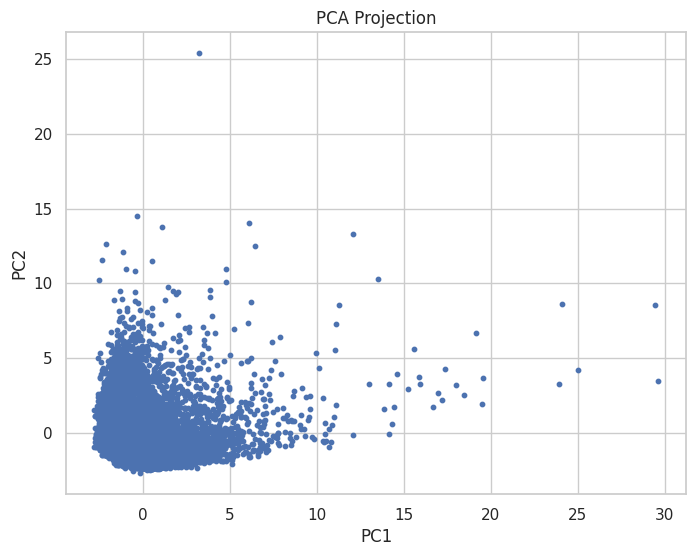

In [43]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    s=10
)

plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

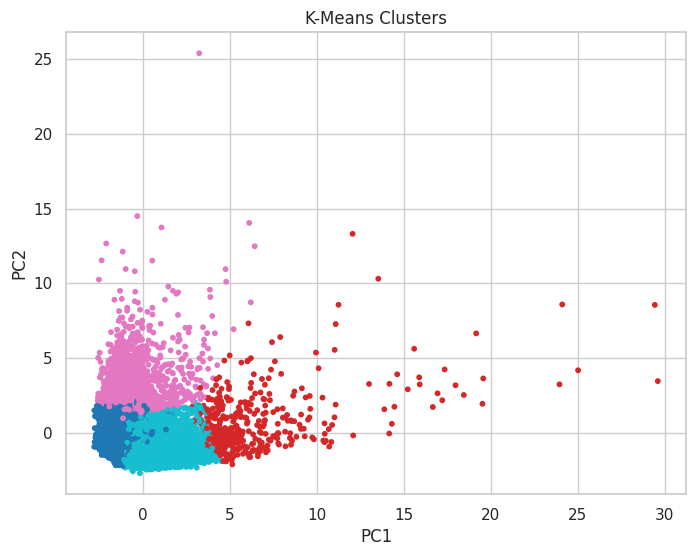

In [44]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=kmeans_labels,
    cmap='tab10',
    s=10
)

plt.title("K-Means Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

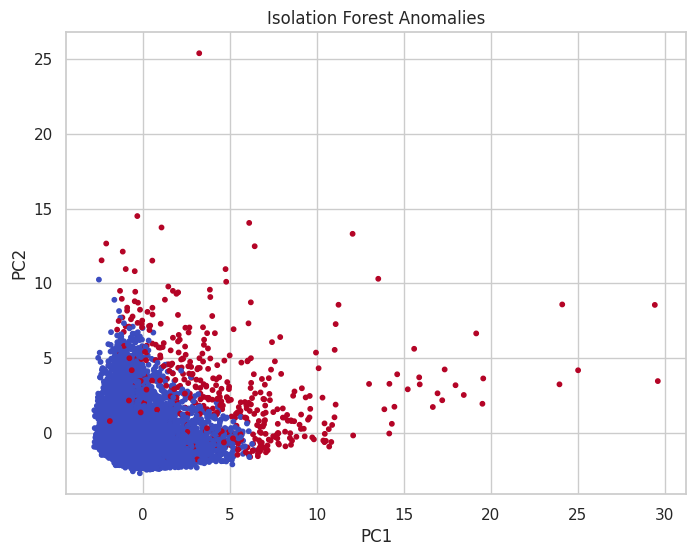

In [45]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=if_anomalies,
    cmap='coolwarm',
    s=10
)

plt.title("Isolation Forest Anomalies")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

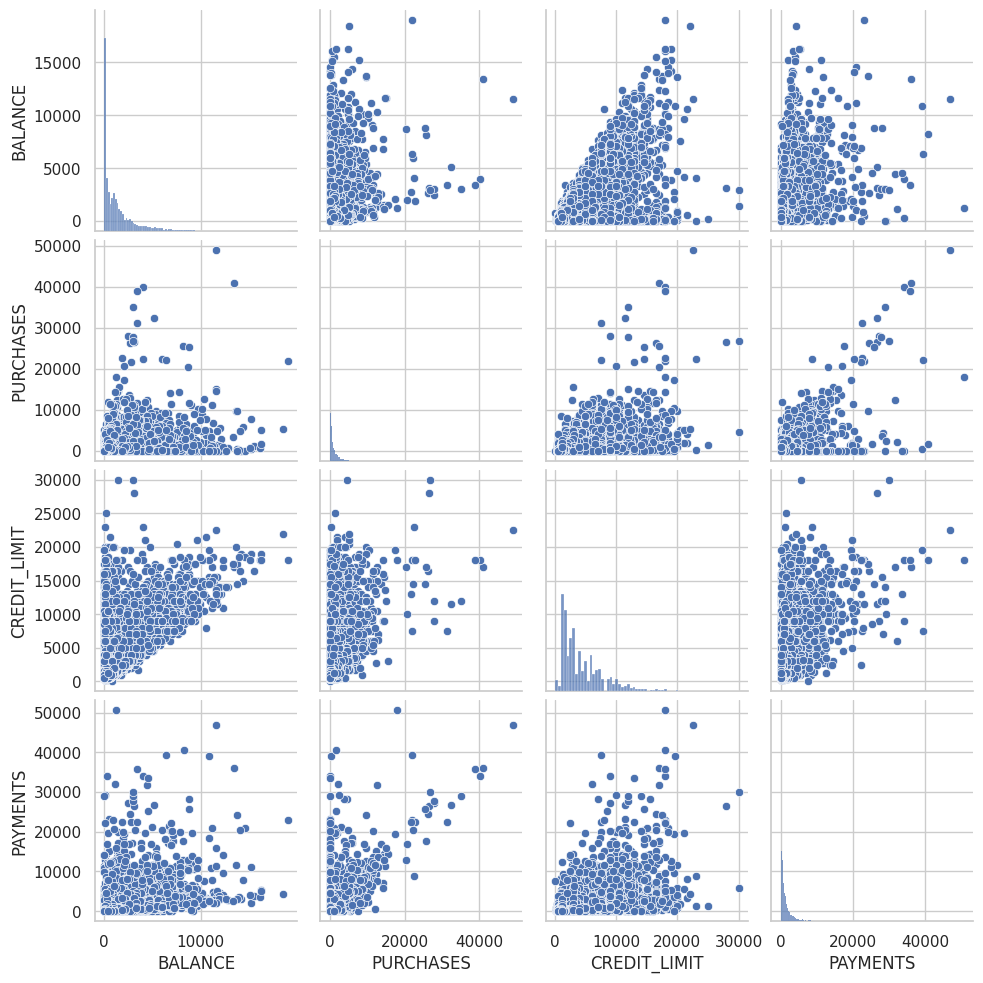

In [46]:
selected_features = [
    'BALANCE',
    'PURCHASES',
    'CREDIT_LIMIT',
    'PAYMENTS'
]

sns.pairplot(
    df[selected_features]
)

plt.show()

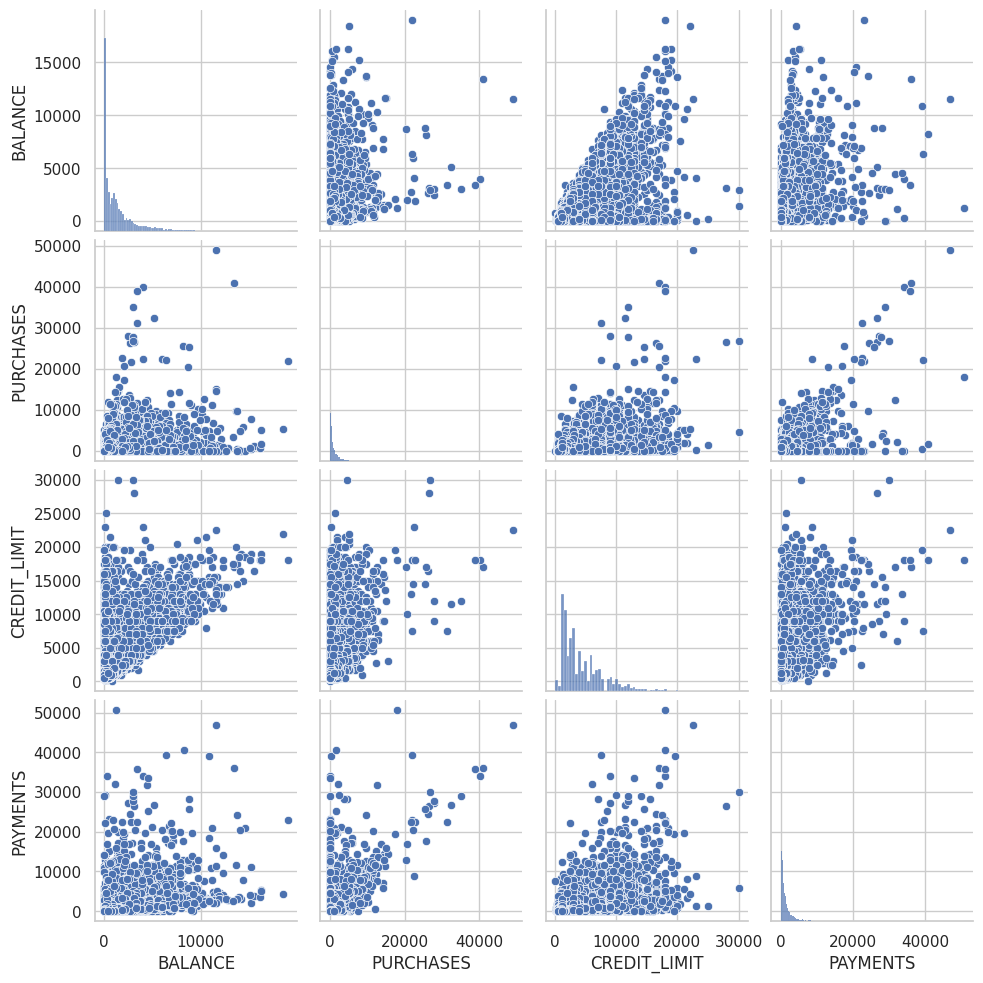

In [47]:
selected_features = [
    'BALANCE',
    'PURCHASES',
    'CREDIT_LIMIT',
    'PAYMENTS'
]

sns.pairplot(
    df[selected_features]
)

plt.show()

## Dashboard Summary

The visualizations provide a compact overview of the dataset structure.

The PCA projection reveals the global structure of the customer population, the clustering visualization highlights potential customer segments, and the anomaly visualizations identify unusual observations.

The pairplots and correlation heatmap further illustrate relationships between the main financial variables and support the findings obtained throughout the analysis.

# Conclusion

This project explored customer behavior using dimensionality reduction, clustering, and anomaly detection techniques.

The results showed that the dataset contains meaningful structure, but also overlapping customer groups and ambiguous anomalies. Different methods produced different results, highlighting the importance of understanding both the data and the assumptions behind each algorithm.